# DeepCFD GNN Testing

Notebook di testing dedicato al confronto tra:
- UNet-Base (data-only)
- GNN (data-only)
- GNN (+physics)

Le figure generate replicano le stesse tipologie del testing precedente (curve, confronto campi, mappe errore, distribuzioni, errori relativi, speedup, residuals).

In [28]:
import os
import csv
import time
import pickle
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from src.models import build_model, PhysicsInformedLoss, count_params

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Device: {device}')

Device: cuda


In [29]:
with open('dataset/dataX.pkl', 'rb') as f:
    X = pickle.load(f)
with open('dataset/dataY.pkl', 'rb') as f:
    Y = pickle.load(f)

X = torch.tensor(X, dtype=torch.float32)
Y = torch.tensor(Y, dtype=torch.float32)

split_candidates = ['checkpoints/data_splits.pt', 'data_splits.pt']
split_path = next((p for p in split_candidates if os.path.exists(p)), None)

if split_path is not None:
    splits = torch.load(split_path, map_location='cpu')
    if 'test_x' in splits and 'test_y' in splits:
        test_x = splits['test_x'].float()
        test_y = splits['test_y'].float()
    elif 'test_idx' in splits:
        test_idx = splits['test_idx']
        test_x = X[test_idx]
        test_y = Y[test_idx]
    else:
        raise KeyError(f'Unsupported split format in {split_path}')
    print(f'Loaded test split from {split_path}: {len(test_x)} samples')
else:
    test_idx = torch.arange(int(0.85 * len(X)), len(X))
    test_x = X[test_idx]
    test_y = Y[test_idx]
    print('No split file found: using fallback tail split (15%).')

BATCH_SIZE = 32
test_loader = DataLoader(TensorDataset(test_x, test_y), batch_size=BATCH_SIZE, shuffle=False)

_, C_in, H, W = test_x.shape
print(f'Test tensor shape: {test_x.shape}')

Loaded test split from checkpoints/data_splits.pt: 148 samples
Test tensor shape: torch.Size([148, 3, 172, 79])


/tmp/ipykernel_1226740/3839717279.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  splits = torch.load(split_path, map_location='cpu')


In [30]:
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, n_layers=2, dropout=0.0):
        super().__init__()
        layers = []
        d = in_dim
        for _ in range(n_layers - 1):
            layers += [nn.Linear(d, hidden_dim), nn.ReLU(inplace=True)]
            if dropout > 0:
                layers += [nn.Dropout(dropout)]
            d = hidden_dim
        layers += [nn.Linear(d, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class GraphBlock(nn.Module):
    def __init__(self, latent_dim, edge_feat_dim=3):
        super().__init__()
        self.edge_mlp = MLP(2 * latent_dim + edge_feat_dim, latent_dim, latent_dim, n_layers=2)
        self.node_mlp = MLP(2 * latent_dim, latent_dim, latent_dim, n_layers=2)

    def forward(self, h, edge_index, edge_attr):
        src, dst = edge_index
        m_in = torch.cat([h[src], h[dst], edge_attr], dim=-1)
        m = self.edge_mlp(m_in)
        agg = torch.zeros_like(h)
        agg.index_add_(0, dst, m)
        h_upd = self.node_mlp(torch.cat([h, agg], dim=-1))
        return h + h_upd

class GridGNN(nn.Module):
    def __init__(self, in_channels=3, out_channels=3, latent_dim=128, n_message_passing=6):
        super().__init__()
        self.encoder = MLP(in_channels + 2, latent_dim, latent_dim, n_layers=2)
        self.processor = nn.ModuleList([GraphBlock(latent_dim, edge_feat_dim=3) for _ in range(n_message_passing)])
        self.decoder = MLP(latent_dim, latent_dim, out_channels, n_layers=2)

    def _forward_single(self, x_single, edge_index, edge_attr, node_coords):
        c_in, h, w = x_single.shape
        x_nodes = x_single.permute(1, 2, 0).reshape(h * w, c_in)
        h_lat = self.encoder(torch.cat([x_nodes, node_coords], dim=-1))
        for block in self.processor:
            h_lat = block(h_lat, edge_index, edge_attr)
        y_nodes = self.decoder(h_lat)
        y_grid = y_nodes.reshape(h, w, -1).permute(2, 0, 1)
        return y_grid

    def forward(self, x, edge_index, edge_attr, node_coords):
        ys = []
        for b in range(x.shape[0]):
            ys.append(self._forward_single(x[b], edge_index, edge_attr, node_coords))
        return torch.stack(ys, dim=0)

def build_grid_graph(H, W, device='cpu'):
    edges_src, edges_dst, edge_attr = [], [], []

    def node_id(i, j):
        return i * W + j

    for i in range(H):
        for j in range(W):
            u = node_id(i, j)
            for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                ni, nj = i + di, j + dj
                if 0 <= ni < H and 0 <= nj < W:
                    v = node_id(ni, nj)
                    edges_src.append(u)
                    edges_dst.append(v)
                    dx = di / max(H - 1, 1)
                    dy = dj / max(W - 1, 1)
                    dist = (dx * dx + dy * dy) ** 0.5
                    edge_attr.append([dx, dy, dist])

    edge_index = torch.tensor([edges_src, edges_dst], dtype=torch.long, device=device)
    edge_attr = torch.tensor(edge_attr, dtype=torch.float32, device=device)

    coords = []
    for i in range(H):
        for j in range(W):
            coords.append([i / max(H - 1, 1), j / max(W - 1, 1)])
    node_coords = torch.tensor(coords, dtype=torch.float32, device=device)

    return edge_index, edge_attr, node_coords

edge_index, edge_attr, node_coords = build_grid_graph(H, W, device=device)
print('Graph nodes:', H * W, '| edges:', edge_index.shape[1])

Graph nodes: 13588 | edges: 53850


In [31]:
class GNNEvalWrapper(nn.Module):
    def __init__(self, core, edge_index, edge_attr, node_coords):
        super().__init__()
        self.core = core
        self.edge_index = edge_index
        self.edge_attr = edge_attr
        self.node_coords = node_coords

    def forward(self, x):
        return self.core(x, self.edge_index, self.edge_attr, self.node_coords)

def _ckpt_to_model(ckpt):
    builder = ckpt.get('builder', '')

    if builder == 'gnn_grid':
        core = GridGNN(
            in_channels=ckpt.get('in_channels', C_in),
            out_channels=ckpt.get('out_channels', 3),
            latent_dim=128,
            n_message_passing=6,
        )
        core.load_state_dict(ckpt['state_dict'])
        model = GNNEvalWrapper(core, edge_index, edge_attr, node_coords).to(device).eval()
        return model

    kwargs = {}
    if 'filters' in ckpt:
        kwargs['filters'] = ckpt['filters']
    if 'input_hw' in ckpt:
        kwargs['input_hw'] = ckpt['input_hw']
    model = build_model(builder, **kwargs)
    model.load_state_dict(ckpt['state_dict'])
    model = model.to(device).eval()
    return model

def load_selected_results(ckpt_dir='checkpoints'):
    wanted = {'base_data', 'gnn_data', 'gnn_phys'}
    results = {}

    for fn in sorted(os.listdir(ckpt_dir)):
        if not (fn.startswith('model_') and fn.endswith('.pt')):
            continue
        ckpt = torch.load(os.path.join(ckpt_dir, fn), map_location='cpu')
        key = ckpt.get('key', fn.replace('model_', '').replace('.pt', ''))
        if key not in wanted:
            continue
        results[key] = {
            'tag': ckpt.get('tag', key),
            'model': _ckpt_to_model(ckpt),
            'use_physics': bool(ckpt.get('use_physics', 'phys' in key)),
            'time': float(ckpt.get('time', np.nan)),
            'best_val_loss': float(ckpt.get('best_val_loss', np.nan)),
            'builder': ckpt.get('builder', 'unknown'),
        }

    missing = sorted(wanted - set(results.keys()))
    if missing:
        raise RuntimeError(f'Missing checkpoints for: {missing}')

    histories_main = {}
    histories_gnn = {}
    if os.path.exists('checkpoints/training_history.pkl'):
        histories_main = pickle.load(open('checkpoints/training_history.pkl', 'rb'))
    if os.path.exists('checkpoints/training_history_gnn.pkl'):
        histories_gnn = pickle.load(open('checkpoints/training_history_gnn.pkl', 'rb'))

    for k in results:
        if k in histories_main:
            results[k]['history'] = histories_main[k]
        if k in histories_gnn:
            results[k]['history'] = histories_gnn[k]

    return results

results = load_selected_results()
print('Loaded models:')
for key in ['base_data', 'gnn_data', 'gnn_phys']:
    r = results[key]
    print(f"  {key:<10} | {r['tag']:<24} | physics={r['use_physics']} | builder={r['builder']}")

Loaded models:
  base_data  | base_data                | physics=False | builder=base
  gnn_data   | GNN (Data only)          | physics=False | builder=gnn_grid
  gnn_phys   | GNN (+Physics)           | physics=True | builder=gnn_grid


/tmp/ipykernel_1226740/3783144334.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(os.path.join(ckpt_dir, fn), map_location='cpu')


In [32]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,
    'axes.titlesize': 9,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)
print(f'Figures folder: {FIG_DIR.resolve()}')

Figures folder: /home/andrea/andrea/AI4E/figures


In [33]:
def predict_all(model, loader):
    model.eval()
    preds, gts, xs = [], [], []
    with torch.no_grad():
        for bx, by in loader:
            out = model(bx.to(device)).cpu()
            preds.append(out)
            gts.append(by)
            xs.append(bx)
    return torch.cat(preds), torch.cat(gts), torch.cat(xs)

def per_sample_sse(pred, gt, fluid_mask):
    sq = (pred - gt) ** 2
    me = fluid_mask.expand_as(sq)
    total = (sq * me).sum(dim=(1, 2, 3))
    per = [(sq[:, c:c+1] * fluid_mask).sum(dim=(1, 2, 3)) for c in range(3)]
    return torch.stack([total, per[0], per[1], per[2]], dim=1)

def per_sample_mse(pred, gt, fluid_mask):
    sq = (pred - gt) ** 2
    me = fluid_mask.expand_as(sq)
    denom_all = me.sum(dim=(1, 2, 3)).clamp_min(1.0)
    denom_ch = fluid_mask.sum(dim=(1, 2, 3)).clamp_min(1.0)
    total = (sq * me).sum(dim=(1, 2, 3)) / denom_all
    per = [((sq[:, c:c+1] * fluid_mask).sum(dim=(1, 2, 3)) / denom_ch) for c in range(3)]
    return torch.stack([total, per[0], per[1], per[2]], dim=1)

cache = {}
for key in ['base_data', 'gnn_data', 'gnn_phys']:
    preds, gts, xs = predict_all(results[key]['model'], test_loader)
    fluid = (xs[:, 1:2] > 0.5).float()
    cache[key] = {
        'preds': preds,
        'gts': gts,
        'xs': xs,
        'fluid': fluid,
        'sse': per_sample_sse(preds, gts, fluid),
        'mse': per_sample_mse(preds, gts, fluid),
    }
    print(f"{key}: test MSE={cache[key]['mse'][:,0].mean().item():.4e}")

base_data: test MSE=1.0012e-04
gnn_data: test MSE=1.8548e-04
gnn_phys: test MSE=2.3768e-04


In [34]:
ORDER = ['base_data', 'gnn_data', 'gnn_phys']

def _param_count_for_key(key):
    m = results[key]['model']
    if hasattr(m, 'core'):
        return count_params(m.core)
    return count_params(m)

rows = []
for key in ORDER:
    sse = cache[key]['sse']
    mse = cache[key]['mse']
    rows.append({
        'key': key,
        'tag': results[key]['tag'],
        'params': _param_count_for_key(key),
        'use_physics': int(results[key]['use_physics']),
        'sse_total': sse[:, 0].mean().item(),
        'sse_ux': sse[:, 1].mean().item(),
        'sse_uy': sse[:, 2].mean().item(),
        'sse_p': sse[:, 3].mean().item(),
        'mse_total': mse[:, 0].mean().item(),
        'mse_ux': mse[:, 1].mean().item(),
        'mse_uy': mse[:, 2].mean().item(),
        'mse_p': mse[:, 3].mean().item(),
        'time_s': results[key].get('time', np.nan),
    })

print('| Model | SSE total | MSE total | Physics |')
print('|-------|----------:|----------:|--------:|')
for r in rows:
    print(f"| {r['tag']} | {r['sse_total']:.4f} | {r['mse_total']:.4e} | {r['use_physics']} |")

with open(FIG_DIR / 'table_test_errors_gnn.csv', 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    w.writeheader()
    w.writerows(rows)
print(f"Saved {FIG_DIR / 'table_test_errors_gnn.csv'}")

m_data = cache['gnn_data']['mse'][:, 0].mean().item()
m_phys = cache['gnn_phys']['mse'][:, 0].mean().item()
gain = 100.0 * (m_data - m_phys) / (m_data + 1e-12)

gain_rows = [{
    'architecture': 'GNN',
    'mse_data_only': m_data,
    'mse_physics': m_phys,
    'relative_gain_percent': gain,
}]

print('\nPhysics-informed gain:')
print('| Architecture | MSE data-only | MSE + physics | Gain [%] |')
print('|--------------|--------------:|--------------:|---------:|')
print(f"| GNN | {m_data:.4e} | {m_phys:.4e} | {gain:+.2f} |")

with open(FIG_DIR / 'table_data_vs_physics_gnn.csv', 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=list(gain_rows[0].keys()))
    w.writeheader()
    w.writerows(gain_rows)
print(f"Saved {FIG_DIR / 'table_data_vs_physics_gnn.csv'}")

| Model | SSE total | MSE total | Physics |
|-------|----------:|----------:|--------:|
| base_data | 3.9596 | 1.0012e-04 | 0 |
| GNN (Data only) | 7.3178 | 1.8548e-04 | 0 |
| GNN (+Physics) | 9.3666 | 2.3768e-04 | 1 |
Saved figures/table_test_errors_gnn.csv

Physics-informed gain:
| Architecture | MSE data-only | MSE + physics | Gain [%] |
|--------------|--------------:|--------------:|---------:|
| GNN | 1.8548e-04 | 2.3768e-04 | -28.14 |
Saved figures/table_data_vs_physics_gnn.csv


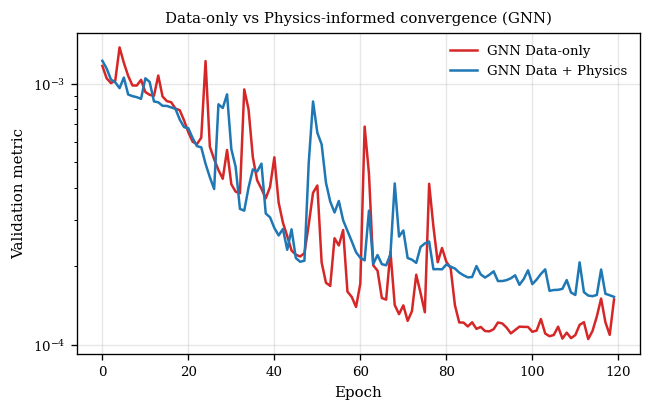

Saved figures/fig_data_vs_physics_curves_gnn.pdf


In [35]:
def _extract_val_series(history_obj):
    if history_obj is None:
        return None, None

    if isinstance(history_obj, dict):
        val_hist = history_obj.get('val', [])
        if isinstance(val_hist, list) and len(val_hist) > 0:
            first = val_hist[0]
            if isinstance(first, dict):
                if 'mse' in first:
                    return [float(e['mse']) for e in val_hist if 'mse' in e], 'Validation MSE'
                if 'loss' in first:
                    return [float(e['loss']) for e in val_hist if 'loss' in e], 'Validation loss'

    if isinstance(history_obj, list) and len(history_obj) > 0:
        first = history_obj[0]
        if isinstance(first, dict):
            if 'mse' in first:
                return [float(e['mse']) for e in history_obj if 'mse' in e], 'Validation MSE'
            if 'loss' in first:
                return [float(e['loss']) for e in history_obj if 'loss' in e], 'Validation loss'
        if isinstance(first, (tuple, list)) and len(first) >= 2:
            return [float(e[1]) for e in history_obj], 'Validation loss'

    return None, None

if all('history' in results[k] for k in ['gnn_data', 'gnn_phys']):
    fig, ax = plt.subplots(1, 1, figsize=(5.5, 3.5))

    y_data, lbl_data = _extract_val_series(results['gnn_data']['history'])
    y_phys, lbl_phys = _extract_val_series(results['gnn_phys']['history'])

    if y_data is not None and y_phys is not None and len(y_data) > 0 and len(y_phys) > 0:
        ax.plot(y_data, label='GNN Data-only', color='#d62728', linewidth=1.5)
        ax.plot(y_phys, label='GNN Data + Physics', color='#1f77b4', linewidth=1.5)
        if all(v > 0 for v in y_data + y_phys):
            ax.set_yscale('log')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Validation metric')
        ax.set_title('Data-only vs Physics-informed convergence (GNN)')
        ax.grid(True, alpha=0.3)
        ax.legend(frameon=False)
        fig.tight_layout()
        out = FIG_DIR / 'fig_data_vs_physics_curves_gnn.pdf'
        fig.savefig(out)
        fig.savefig(out.with_suffix('.png'))
        plt.show()
        print(f'Saved {out}')
    else:
        print('History format not plottable for GNN curves.')
else:
    print('GNN histories not found: skipping convergence plot.')

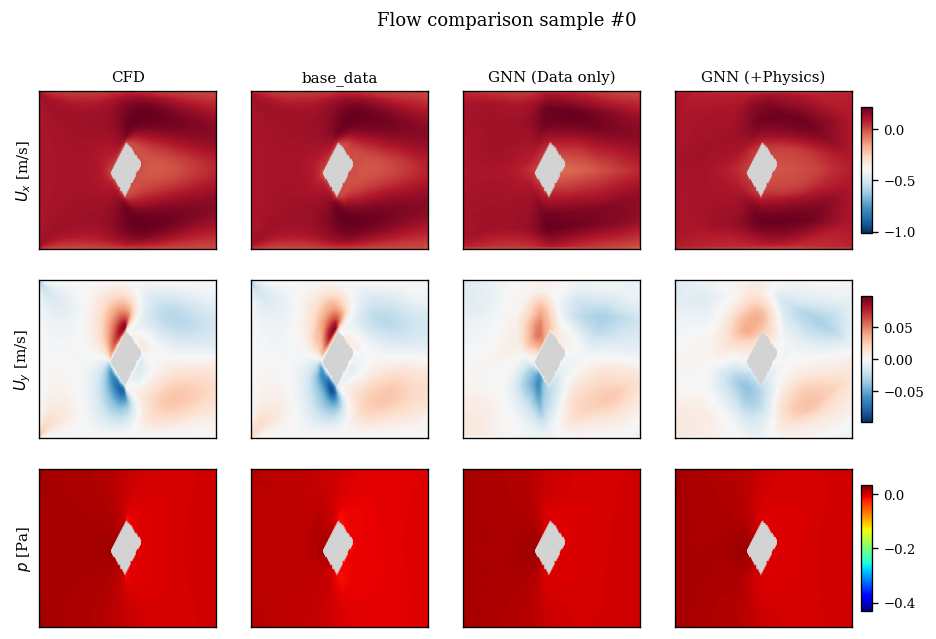

Saved figures/fig_flow_compare_data_phys_gnn_sample_0.pdf


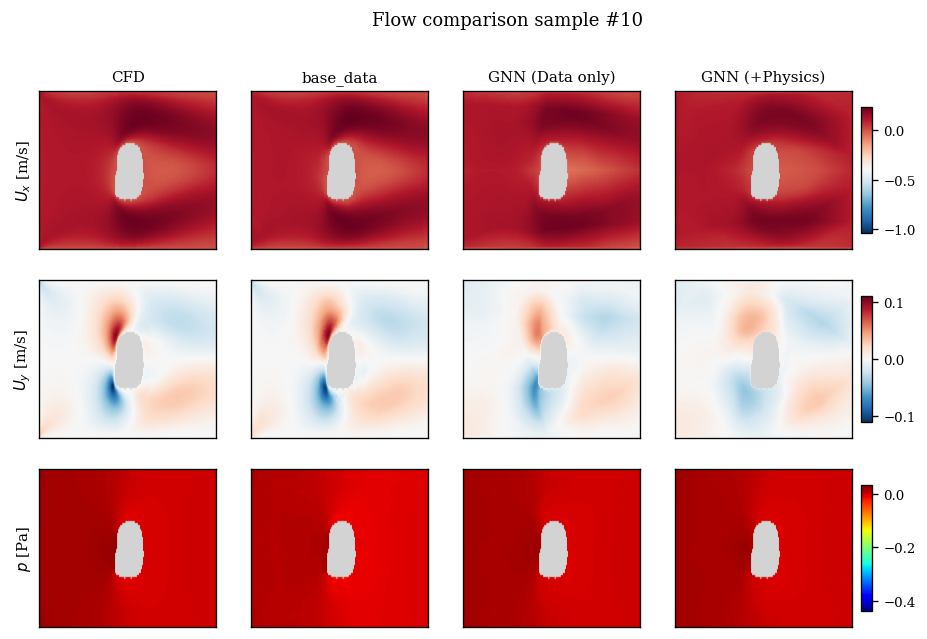

Saved figures/fig_flow_compare_data_phys_gnn_sample_10.pdf


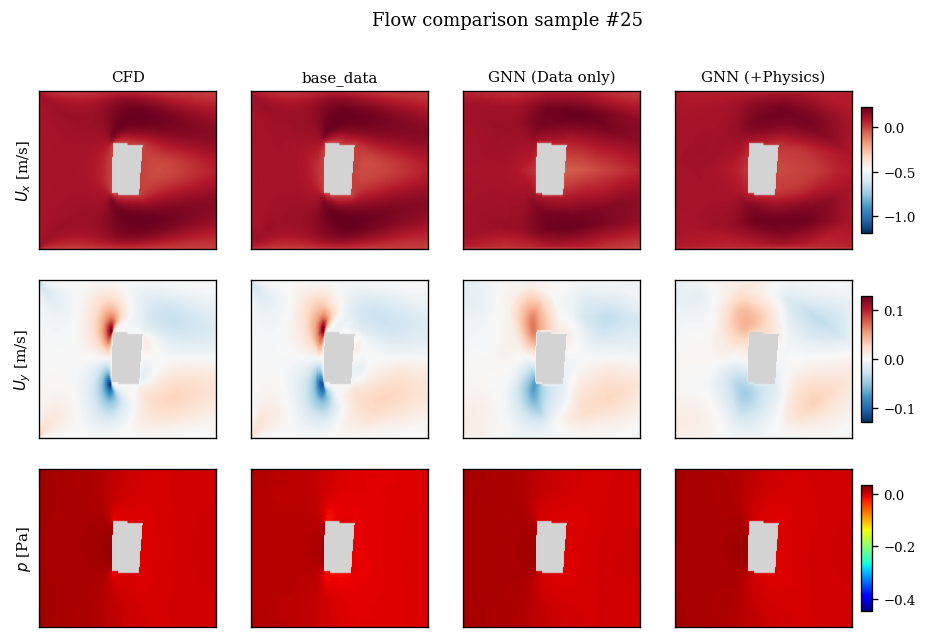

Saved figures/fig_flow_compare_data_phys_gnn_sample_25.pdf


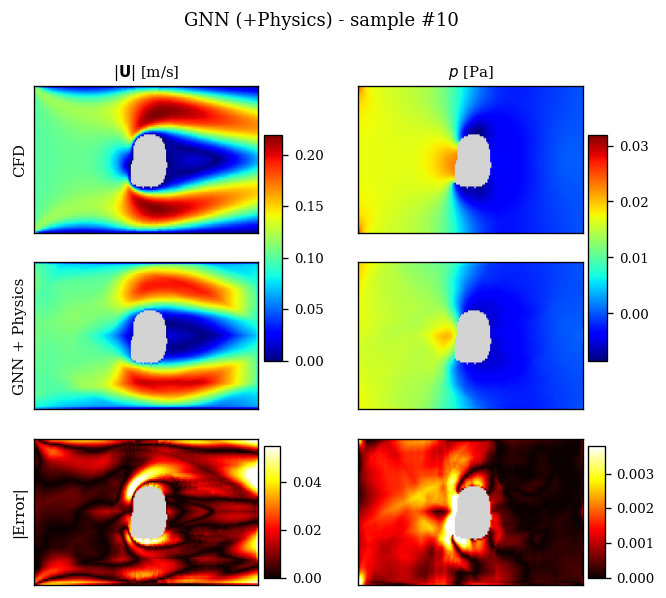

Saved figures/fig_umag_p_error_gnn_phys_sample10.pdf


In [36]:
FIELDS = [('Ux', r'$U_x$ [m/s]'), ('Uy', r'$U_y$ [m/s]'), ('p', r'$p$ [Pa]')]

def obstacle_mask_from_x(x_sample):
    return (x_sample[1] < 0.5).numpy()

def _masked_field(field_np, obs):
    return np.ma.array(field_np, mask=obs)

def fig_flow_comparison(sample_idx, model_keys, filename):
    n_cols = 1 + len(model_keys)
    fig, axes = plt.subplots(3, n_cols, figsize=(2.6 * n_cols, 5.8))
    gt = test_y[sample_idx].numpy()
    x_s = test_x[sample_idx]
    obs = obstacle_mask_from_x(x_s)

    cmap_vel = mpl.colormaps.get_cmap('RdBu_r').copy(); cmap_vel.set_bad('lightgray', 1.0)
    cmap_p = mpl.colormaps.get_cmap('jet').copy(); cmap_p.set_bad('lightgray', 1.0)

    for row, (_, label) in enumerate(FIELDS):
        all_data = [gt[row]] + [cache[k]['preds'][sample_idx, row].numpy() for k in model_keys]
        vmin = min(d.min() for d in all_data)
        vmax = max(d.max() for d in all_data)
        if row == 1:
            v = max(abs(vmin), abs(vmax))
            vmin, vmax = -v, v
        cmap = cmap_p if row == 2 else cmap_vel

        ax0 = axes[row, 0]
        im = ax0.imshow(_masked_field(gt[row], obs).T, cmap=cmap, origin='lower', vmin=vmin, vmax=vmax, aspect='auto')
        ax0.set_ylabel(label)
        if row == 0:
            ax0.set_title('CFD')
        ax0.set_xticks([]); ax0.set_yticks([])

        for col, key in enumerate(model_keys, start=1):
            ax = axes[row, col]
            pred = cache[key]['preds'][sample_idx, row].numpy()
            ax.imshow(_masked_field(pred, obs).T, cmap=cmap, origin='lower', vmin=vmin, vmax=vmax, aspect='auto')
            if row == 0:
                ax.set_title(results[key]['tag'])
            ax.set_xticks([]); ax.set_yticks([])

        fig.colorbar(im, ax=axes[row, :].ravel().tolist(), location='right', shrink=0.8, pad=0.01, aspect=12)

    fig.suptitle(f'Flow comparison sample #{sample_idx}', y=0.995)
    out = FIG_DIR / filename
    fig.savefig(out)
    fig.savefig(out.with_suffix('.png'))
    plt.show()
    print(f'Saved {out}')

for idx in [0, 10, 25]:
    if idx < len(test_x):
        fig_flow_comparison(idx, ['base_data', 'gnn_data', 'gnn_phys'], filename=f'fig_flow_compare_data_phys_gnn_sample_{idx}.pdf')

def fig_umag_p_error(sample_idx, model_key, filename):
    gt = test_y[sample_idx].numpy()
    x_s = test_x[sample_idx]
    obs = obstacle_mask_from_x(x_s)
    pred = cache[model_key]['preds'][sample_idx].numpy()

    umag_gt = np.sqrt(gt[0] ** 2 + gt[1] ** 2)
    umag_pr = np.sqrt(pred[0] ** 2 + pred[1] ** 2)
    p_gt = gt[2]; p_pr = pred[2]
    err_umag = np.abs(umag_pr - umag_gt)
    err_p = np.abs(p_pr - p_gt)

    fig, axes = plt.subplots(3, 2, figsize=(6.4, 5.4))
    cmap_jet = mpl.colormaps.get_cmap('jet').copy(); cmap_jet.set_bad('lightgray', 1.0)
    cmap_err = mpl.colormaps.get_cmap('hot').copy(); cmap_err.set_bad('lightgray', 1.0)

    row_labels = ['CFD', 'GNN + Physics', '|Error|']
    umag_max = max(umag_gt.max(), umag_pr.max())
    p_vmin = min(p_gt.min(), p_pr.min())
    p_vmax = max(p_gt.max(), p_pr.max())

    def _plot(ax, img, cmap, vmin=None, vmax=None):
        m = np.ma.array(img, mask=obs)
        im = ax.imshow(m.T, cmap=cmap, origin='lower', vmin=vmin, vmax=vmax, aspect='auto')
        ax.set_xticks([]); ax.set_yticks([])
        return im

    im_u0 = _plot(axes[0, 0], umag_gt, cmap_jet, 0, umag_max)
    im_p0 = _plot(axes[0, 1], p_gt, cmap_jet, p_vmin, p_vmax)
    _plot(axes[1, 0], umag_pr, cmap_jet, 0, umag_max)
    _plot(axes[1, 1], p_pr, cmap_jet, p_vmin, p_vmax)
    err_u_max = np.percentile(err_umag[~obs], 99)
    err_p_max = np.percentile(err_p[~obs], 99)
    im_u2 = _plot(axes[2, 0], err_umag, cmap_err, 0, err_u_max)
    im_p2 = _plot(axes[2, 1], err_p, cmap_err, 0, err_p_max)

    for i, lbl in enumerate(row_labels):
        axes[i, 0].set_ylabel(lbl)
    axes[0, 0].set_title(r'$|\mathbf{U}|$ [m/s]')
    axes[0, 1].set_title(r'$p$ [Pa]')

    fig.colorbar(im_u0, ax=axes[0:2, 0].ravel().tolist(), location='right', shrink=0.7, pad=0.02, aspect=12)
    fig.colorbar(im_p0, ax=axes[0:2, 1].ravel().tolist(), location='right', shrink=0.7, pad=0.02, aspect=12)
    fig.colorbar(im_u2, ax=[axes[2, 0]], location='right', shrink=0.9, pad=0.02, aspect=8)
    fig.colorbar(im_p2, ax=[axes[2, 1]], location='right', shrink=0.9, pad=0.02, aspect=8)

    fig.suptitle(f'GNN (+Physics) - sample #{sample_idx}', y=0.995)
    out = FIG_DIR / filename
    fig.savefig(out)
    fig.savefig(out.with_suffix('.png'))
    plt.show()
    print(f'Saved {out}')

sample_idx = 10 if len(test_x) > 10 else 0
fig_umag_p_error(sample_idx, 'gnn_phys', filename=f'fig_umag_p_error_gnn_phys_sample{sample_idx}.pdf')

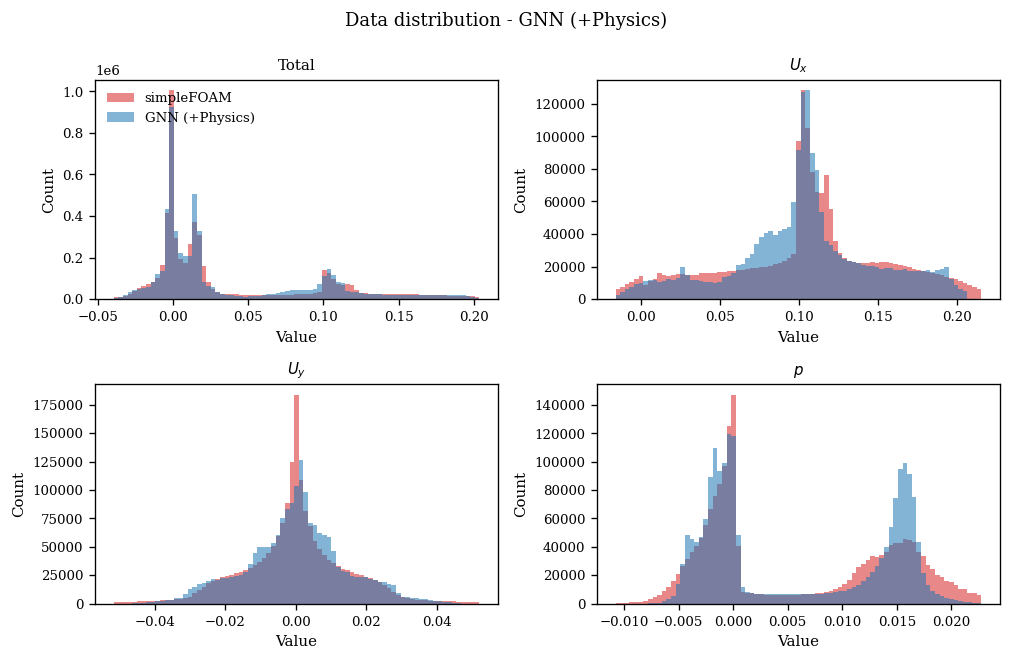

Saved figures/fig_distribution_gnn_phys.pdf


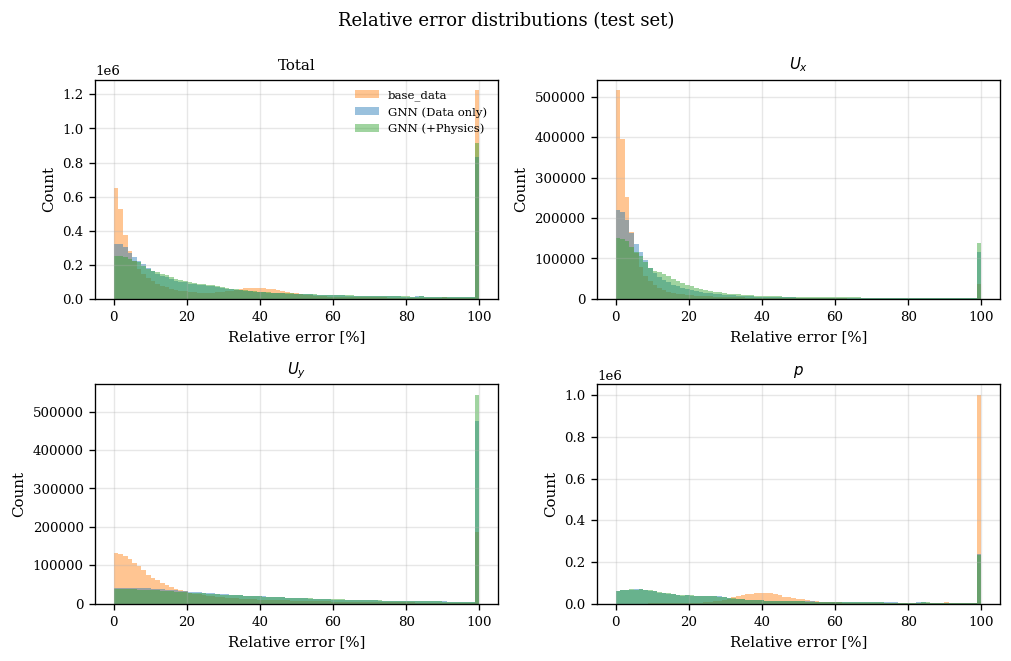

Saved figures/fig_relative_errors_gnn.pdf


In [37]:
def collect_fluid_values(arr4d, mask4d, channel=None):
    if channel is not None:
        a = arr4d[:, channel:channel+1]
        m = mask4d
    else:
        a = arr4d
        m = mask4d.expand_as(arr4d)
    return a[m.bool()].numpy()

def fig_distribution(model_key, filename):
    ck = cache[model_key]
    preds, gts, m = ck['preds'], ck['gts'], ck['fluid']
    fig, axes = plt.subplots(2, 2, figsize=(8.5, 5.5))
    axes = axes.flat
    panels = [(None, 'Total', axes[0]), (0, r'$U_x$', axes[1]), (1, r'$U_y$', axes[2]), (2, r'$p$', axes[3])]

    for ch, title, ax in panels:
        a_gt = collect_fluid_values(gts, m, ch)
        a_pr = collect_fluid_values(preds, m, ch)
        lo = np.percentile(np.concatenate([a_gt, a_pr]), 0.5)
        hi = np.percentile(np.concatenate([a_gt, a_pr]), 99.5)
        bins = np.linspace(lo, hi, 80)
        ax.hist(a_gt, bins=bins, alpha=0.55, color='#d62728', label='simpleFOAM')
        ax.hist(a_pr, bins=bins, alpha=0.55, color='#1f77b4', label=results[model_key]['tag'])
        ax.set_title(title)
        ax.set_xlabel('Value')
        ax.set_ylabel('Count')

    axes[0].legend(loc='upper left', frameon=False)
    fig.suptitle(f'Data distribution - {results[model_key]["tag"]}', y=0.99)
    fig.tight_layout()
    out = FIG_DIR / filename
    fig.savefig(out)
    fig.savefig(out.with_suffix('.png'))
    plt.show()
    print(f'Saved {out}')

fig_distribution('gnn_phys', filename='fig_distribution_gnn_phys.pdf')

K = 1e-4

def relative_errors(pred, gt, mask, channel=None):
    if channel is not None:
        p = pred[:, channel:channel+1]
        g = gt[:, channel:channel+1]
        m = mask
    else:
        p = pred
        g = gt
        m = mask.expand_as(pred)
    rel = (p - g).abs() / (g.abs() + K) * 100.0
    return rel[m.bool()].numpy()

def fig_relative_errors(model_keys, filename, clip_pct=100):
    colors = ['#ff7f0e', '#1f77b4', '#2ca02c']
    fig, axes = plt.subplots(2, 2, figsize=(8.5, 5.5))
    axes = axes.flat
    bins = np.linspace(0, clip_pct, 80)
    panels = [(None, 'Total', axes[0]), (0, r'$U_x$', axes[1]), (1, r'$U_y$', axes[2]), (2, r'$p$', axes[3])]

    for ch, title, ax in panels:
        for i, key in enumerate(model_keys):
            rel = relative_errors(cache[key]['preds'], cache[key]['gts'], cache[key]['fluid'], channel=ch)
            rel = np.clip(rel, 0, clip_pct)
            ax.hist(rel, bins=bins, alpha=0.45, color=colors[i % len(colors)], label=results[key]['tag'])
        ax.set_title(title)
        ax.set_xlabel('Relative error [%]')
        ax.set_ylabel('Count')
        ax.grid(True, alpha=0.3)

    axes[0].legend(loc='upper right', frameon=False, fontsize=7)
    fig.suptitle('Relative error distributions (test set)', y=0.99)
    fig.tight_layout()
    out = FIG_DIR / filename
    fig.savefig(out)
    fig.savefig(out.with_suffix('.png'))
    plt.show()
    print(f'Saved {out}')

fig_relative_errors(['base_data', 'gnn_data', 'gnn_phys'], filename='fig_relative_errors_gnn.pdf')

In [38]:
CFD_TIME_S = 52.51
BATCH_SIZES = [1, 10, 100]
N_RUNS = 30
x_single = test_x[0:1].to(device)

def time_inference(model, batch_size, n_runs=N_RUNS):
    model.eval()
    x_batch = x_single.repeat(batch_size, 1, 1, 1)
    with torch.no_grad():
        for _ in range(3):
            _ = model(x_batch)
    if device.type == 'cuda':
        torch.cuda.synchronize()

    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            if device.type == 'cuda':
                torch.cuda.synchronize()
            t0 = time.perf_counter()
            _ = model(x_batch)
            if device.type == 'cuda':
                torch.cuda.synchronize()
            times.append(time.perf_counter() - t0)
    t = np.array(times)
    return float(t.mean()), float(t.std())

rows_time = []
for key in ORDER:
    m = results[key]['model']
    row = {'key': key, 'tag': results[key]['tag'], 'params': _param_count_for_key(key)}
    for bs in BATCH_SIZES:
        mu, sd = time_inference(m, bs)
        per_sample = mu / bs
        speedup = CFD_TIME_S / (per_sample + 1e-12)
        row[f'time_bs{bs}_s'] = mu
        row[f'time_bs{bs}_std'] = sd
        row[f'per_sample_bs{bs}'] = per_sample
        row[f'speedup_bs{bs}'] = speedup
    rows_time.append(row)

with open(FIG_DIR / 'table_inference_speedup_gnn.csv', 'w', newline='') as f:
    w = csv.DictWriter(f, fieldnames=list(rows_time[0].keys()))
    w.writeheader()
    w.writerows(rows_time)
print(f"Saved {FIG_DIR / 'table_inference_speedup_gnn.csv'}")

Saved figures/table_inference_speedup_gnn.csv


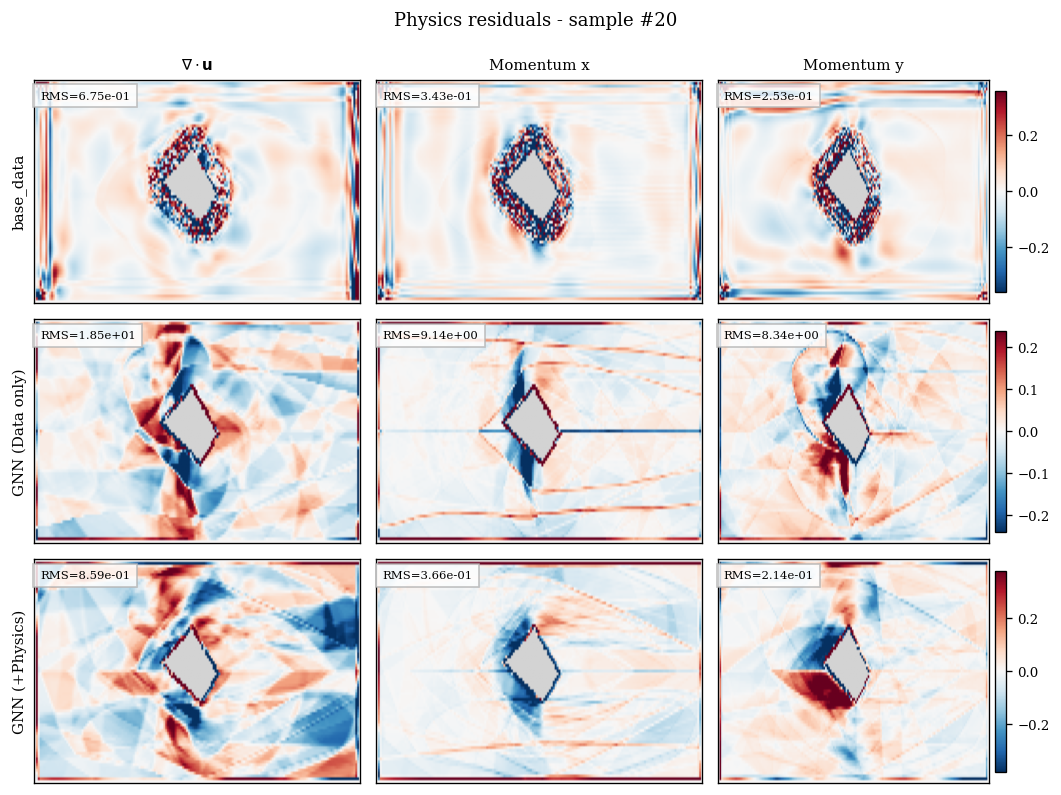

Saved figures/fig_residuals_gnn.pdf
Artifacts in figures/:
  fig_data_vs_physics_curves_gnn.pdf
  fig_data_vs_physics_curves_gnn.png
  fig_distribution_gnn_phys.pdf
  fig_distribution_gnn_phys.png
  fig_flow_compare_data_phys_gnn_sample_0.pdf
  fig_flow_compare_data_phys_gnn_sample_0.png
  fig_flow_compare_data_phys_gnn_sample_10.pdf
  fig_flow_compare_data_phys_gnn_sample_10.png
  fig_flow_compare_data_phys_gnn_sample_25.pdf
  fig_flow_compare_data_phys_gnn_sample_25.png
  fig_gnn_training_summary.png
  fig_relative_errors_gnn.pdf
  fig_relative_errors_gnn.png
  fig_residuals_gnn.pdf
  fig_residuals_gnn.png
  fig_umag_p_error_gnn_phys_sample10.pdf
  fig_umag_p_error_gnn_phys_sample10.png
  table_data_vs_physics_gnn.csv
  table_inference_speedup_gnn.csv
  table_test_errors_gnn.csv


In [39]:
phys = PhysicsInformedLoss().to(device)

def compute_residuals(model, x_sample):
    model.eval()
    with torch.no_grad():
        x_in = x_sample.unsqueeze(0).to(device)
        y = model(x_in)
        ux, uy, p = y[:, 0:1], y[:, 1:2], y[:, 2:3]
        m = phys.region_masks(x_in)['interior']

        div = (phys.ddx(ux) + phys.ddy(uy)) * m
        res_x = (ux * phys.ddx(ux) + uy * phys.ddy(ux) + phys.ddx(p) - phys.nu * (phys.d2dx2(ux) + phys.d2dy2(ux))) * m
        res_y = (ux * phys.ddx(uy) + uy * phys.ddy(uy) + phys.ddy(p) - phys.nu * (phys.d2dx2(uy) + phys.d2dy2(uy))) * m

    obs = (x_sample[1] < 0.5).numpy()
    return div[0, 0].cpu().numpy(), res_x[0, 0].cpu().numpy(), res_y[0, 0].cpu().numpy(), obs

def fig_residuals(sample_idx, model_keys, filename):
    fig, axes = plt.subplots(len(model_keys), 3, figsize=(9.0, 2.2 * len(model_keys)))
    if len(model_keys) == 1:
        axes = axes[None, :]

    cmap = mpl.colormaps.get_cmap('RdBu_r').copy(); cmap.set_bad('lightgray', 1.0)
    col_titles = [r'$\nabla \cdot \mathbf{u}$', 'Momentum x', 'Momentum y']

    for row, key in enumerate(model_keys):
        div, rx, ry, obs = compute_residuals(results[key]['model'], test_x[sample_idx])
        data = [div, rx, ry]
        for col in range(3):
            d = data[col]
            vmax = np.percentile(np.abs(d[~obs]), 97)
            vmax = max(vmax, 1e-12)
            m = np.ma.array(d, mask=obs)
            im = axes[row, col].imshow(m.T, cmap=cmap, origin='lower', vmin=-vmax, vmax=vmax, aspect='auto')
            axes[row, col].set_xticks([])
            axes[row, col].set_yticks([])
            if row == 0:
                axes[row, col].set_title(col_titles[col])
            rms = float(np.sqrt(np.mean(d[~obs] ** 2)))
            axes[row, col].text(0.02, 0.95, f'RMS={rms:.2e}', transform=axes[row, col].transAxes, va='top', fontsize=7,
                                bbox=dict(facecolor='white', alpha=0.8, edgecolor='0.7'))
            if col == 2:
                fig.colorbar(im, ax=axes[row, col], shrink=0.9, pad=0.02)
        axes[row, 0].set_ylabel(results[key]['tag'])

    fig.suptitle(f'Physics residuals - sample #{sample_idx}', y=0.995)
    fig.tight_layout()
    out = FIG_DIR / filename
    fig.savefig(out)
    fig.savefig(out.with_suffix('.png'))
    plt.show()
    print(f'Saved {out}')

sample_idx = 20 if len(test_x) > 20 else 0
fig_residuals(sample_idx, ['base_data', 'gnn_data', 'gnn_phys'], filename='fig_residuals_gnn.pdf')

print('Artifacts in figures/:')
for p in sorted(FIG_DIR.glob('*gnn*')):
    print(' ', p.name)